# Практическое занятие 1. Инженерные данные и постановка задачи прикладного искусственного интеллекта Версия преподавателя

## Назначение занятия

Цель занятия - освоить первичный анализ инженерной таблицы данных на примере
маломощного высокооборотного электромеханического преобразователя на постоянных
магнитах.

Искусственный интеллект (Artificial Intelligence, AI) в данном занятии
понимается как совокупность методов извлечения закономерностей из данных.
Машинное обучение (Machine Learning, ML) - раздел искусственного интеллекта,
в котором модель настраивает параметры по наблюдениям.

К концу занятия студент должен уметь:

1. загрузить таблицу данных;
2. различить наблюдение, признак и целевую переменную;
3. обнаружить пропуски и возможные выбросы;
4. построить первичные графики;
5. сформулировать инженерный вывод с учетом единиц измерения.


## Основные определения

Наблюдение - одна строка таблицы, соответствующая одному режиму работы.
Признак (feature) - входная величина, которую можно использовать для анализа
или обучения модели. Целевая переменная (target variable) - величина, которую
требуется объяснить, предсказать или классифицировать.

Коэффициент полезного действия, КПД, обозначается `efficiency` и отражает
отношение полезной выходной мощности к входной электрической мощности. В
учебной таблице КПД представлен как безразмерная величина от 0 до 1.


## Как устроены модели первичного анализа данных

В занятии 1 не строится прогнозная модель машинного обучения. Тем не менее
используются формальные модели описания данных. Модель данных - это
упрощенное математическое представление объекта анализа. Для табличного
набора данных таким представлением является матрица признаков:

$$X = [x_{ij}], \quad i = 1, ..., n, \quad j = 1, ..., p,$$

где `n` - число наблюдений, `p` - число признаков, `x_ij` - значение признака
`j` в наблюдении `i`. Такая запись позволяет отделить физический объект
измерения от вычислительной формы, в которой он анализируется.

Описательная статистика (descriptive statistics) строит компактное описание
распределения признака. Среднее значение оценивает центральный уровень:

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.$$

Выборочное стандартное отклонение показывает типичный масштаб разброса:

$$s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}.$$

Медиана - значение, которое делит упорядоченную выборку на две равные части.
Квартили - значения, отделяющие четверти упорядоченной выборки. Первый
квартиль `Q1` соответствует 25 %, третий квартиль `Q3` соответствует 75 %.
Межквартильный размах (interquartile range, IQR) определяется как

$$IQR = Q3 - Q1.$$

В учебном анализе кандидатами в выбросы считаются наблюдения за пределами
интервала

$$[Q1 - 1.5 \cdot IQR, \; Q3 + 1.5 \cdot IQR].$$

Это правило не доказывает ошибочность наблюдения. В инженерных данных выброс
может быть следствием неисправности, переходного процесса или редкого, но
физически допустимого режима. Поэтому любое статистическое правило должно
сопоставляться с единицами измерения и физическими ограничениями объекта.

Корреляционный анализ оценивает согласованное изменение двух числовых
признаков. Коэффициент корреляции Пирсона (Pearson correlation coefficient)
вычисляется по формуле

$$r_{xy} =
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}.$$

Значение `r_xy` находится в диапазоне от -1 до 1. Значение около 1 указывает
на сильную прямую линейную связь, значение около -1 - на сильную обратную
линейную связь, значение около 0 - на отсутствие выраженной линейной связи.
Корреляция не является доказательством причинно-следственной зависимости.


## Физическая основа учебного набора данных

Учебная таблица имитирует структуру стендовых измерений постоянно-магнитной
синхронной машины (Permanent Magnet Synchronous Motor, PMSM). Такая машина
имеет ротор с постоянными магнитами и статорную обмотку, создающую вращающееся
магнитное поле. В практических занятиях PMSM используется как инженерный
пример электромеханического преобразователя: входом является электрическая
мощность, а полезным выходом - механическая мощность на валу.

Базовые расчетные соотношения:

$\omega = 2 \pi n / 60$,

$P_{out} = M \omega$,

$P_{in} = U I$,

$\eta = P_{out} / P_{in}$,

$P_{loss} = P_{in} - P_{out}$.

Здесь `omega_rad_s` - угловая скорость в радианах в секунду, `speed_rpm` -
частота вращения в оборотах в минуту, `torque_nm` - момент на валу,
`voltage_v` - напряжение, `current_a` - ток. Реальные испытания требуют учета
методики измерения потерь, теплового состояния и неопределенности датчиков.
Поэтому данный CSV следует рассматривать как воспроизводимый учебный набор:
он согласован с инженерной логикой открытых стендовых данных, но не заменяет
сертификационные испытания конкретного двигателя. В расчетных проверках
допустимо небольшое расхождение из-за округления сохраненных CSV-значений.


## Источники и проверка актуальности

1. ElectricMotorTemperature, Zenodo TSML Archive - открытый набор многомерных временных рядов для регрессии температуры электродвигателя. Используется как реальный ориентир структуры временных признаков. URL: https://zenodo.org/records/11235562
2. IEC 60034-1:2026. Rotating electrical machines - Part 1: Rating and performance. Используется как нормативный ориентир терминологии вращающихся электрических машин. URL: https://webstore.iec.ch/en/publication/89961
3. IEC 60034-2-1:2024. Rotating electrical machines - Part 2-1: Standard methods for determining losses and efficiency from tests. Используется как нормативный ориентир по потерям и КПД. URL: https://webstore.iec.ch/en/publication/67756
4. Документация pandas по пропущенным данным. URL: https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html
5. Документация scikit-learn по моделям, разбиению данных и метрикам качества. URL: https://scikit-learn.org/stable/

Дата проверки актуальности ссылок: 2026-05-07.


## Рекомендуемые реальные наборы данных для занятий 1-2

Базовый учебный CSV в этом блокноте сохраняется для гарантированного запуска
в аудитории. При расширении работы его целесообразно сопоставлять с реальными
открытыми наборами данных:

1. ElectricMotorTemperature, Zenodo TSML Archive. URL:
   https://zenodo.org/records/11235562. Набор содержит открытые
   многомерные временные ряды (multivariate time series, многоканальные
   временные последовательности) для регрессии температуры электродвигателя.
   Применение: первичный анализ данных, регрессия температуры, обсуждение
   временной автокорреляции и группового разбиения. Ограничение: исходный
   формат `.ts` не содержит физических имен каналов, поэтому признаки в
   учебной таблице обозначаются нейтрально: `channel_00_mean`,
   `channel_01_mean` и далее.
2. Zenodo PMSM inverter fault diagnosis. URL:
   https://zenodo.org/records/14482932. Компактный набор измерений
   PMSM-инвертора с режимами отказов, фазными токами, напряжением
   звена постоянного тока и температурными признаками. Применение:
   первичный анализ, классификация и упрощенная регрессия температур.
   Ограничение: исходная постановка ближе к диагностике, чем к расчету КПД.
3. Processed Data for EV Powertrain Efficiency, Mendeley Data. URL:
   https://data.mendeley.com/datasets/kbwr2z8r3y. Набор
   предназначен для анализа эффективности электропривода транспортного
   средства. Применение: дополнительный пример перехода от траекторных
   данных к расчетной карте КПД. Ограничение: КПД является расчетным, а не
   стендовым измерением двигателя.

Методическое решение для эталонного занятия: использовать малый учебный CSV
как обязательный набор, а реальные источники - как расширение для проектов,
докладов и самостоятельной доработки.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


# Поиск корня учебного проекта.
# Если блокнот запускается из корня репозитория, Path.cwd() уже указывает
# на нужный каталог. Если блокнот открыт из папки notebooks/student или
# notebooks/teacher, проверяются родительские каталоги.
candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError(
        "Не найден корень проекта. Запустите блокнот из каталога appai_lab "
        "или укажите путь к проекту вручную."
    )

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


DATA_DIR = PROJECT_ROOT / "data" / "processed"
DATA_FILE = DATA_DIR / "practice_01_motor_measurements.csv"
DIAGNOSTICS_FILE = None
CATALOG_FILE = DATA_DIR / "practice_01_03_dataset_catalog.csv"
ASSIGNMENTS_FILE = DATA_DIR / "practice_01_03_dataset_assignments.csv"

if not DATA_FILE.exists() or not CATALOG_FILE.exists() or not ASSIGNMENTS_FILE.exists():
    raise FileNotFoundError(
        "Не найдены учебные CSV-файлы. Выполните из корня проекта команду "
        "`python scripts/generate_datasets.py`, затем повторно запустите блокнот."
    )

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

RANDOM_STATE = 20260507


def draw_process_diagram(labels, title):
    """Построить простую схему последовательности этапов работы.

    Схема используется как учебная визуализация. Она не является алгоритмом,
    а показывает логическую структуру анализа: от источника данных к выводу.
    """
    fig, ax = plt.subplots(figsize=(max(10, 2.2 * len(labels)), 2.3))
    ax.set_axis_off()
    x_positions = np.linspace(0.06, 0.94, len(labels))

    for index, (x_pos, label) in enumerate(zip(x_positions, labels)):
        box = FancyBboxPatch(
            (x_pos - 0.075, 0.40),
            0.15,
            0.28,
            boxstyle="round,pad=0.02",
            linewidth=1.2,
            edgecolor="black",
            facecolor="#e8f1f8",
            transform=ax.transAxes,
        )
        ax.add_patch(box)
        ax.text(
            x_pos,
            0.54,
            label,
            ha="center",
            va="center",
            fontsize=10,
            wrap=True,
            transform=ax.transAxes,
        )
        if index < len(labels) - 1:
            arrow = FancyArrowPatch(
                (x_pos + 0.085, 0.54),
                (x_positions[index + 1] - 0.085, 0.54),
                arrowstyle="->",
                mutation_scale=12,
                linewidth=1.1,
                color="black",
                transform=ax.transAxes,
            )
            ax.add_patch(arrow)

    ax.set_title(title, fontsize=13, pad=14)
    plt.show()


def plot_correlation_heatmap(data, columns, title):
    """Построить тепловую карту корреляций без дополнительных библиотек."""
    corr = data[columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Коэффициент корреляции")

    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

DATA_FILE


PosixPath('/mnt/f/projects/appai_lab/data/processed/practice_01_motor_measurements.csv')

## Логическая схема занятия

Первичный анализ данных не начинается с обучения модели. Сначала необходимо
понять происхождение данных, физический смысл столбцов и ограничения
измерений. В инженерной задаче это особенно важно, потому что численно
правильная обработка может привести к физически неверному выводу, если
игнорировать единицы измерения, режим работы или происхождение признака.


## Последовательность подготовки данных на этапе первичного анализа

Подготовка данных должна выполняться как воспроизводимая процедура. Это
означает, что каждый шаг должен быть описан так, чтобы другой исследователь
мог повторить обработку и получить тот же результат.

Рекомендуемая последовательность действий:

1. Зафиксировать источник данных: название файла, происхождение, дату
   получения, лицензию и ограничения использования.
2. Определить объект наблюдения: одна строка таблицы, измерительный профиль,
   экспериментальный запуск или окно временного сигнала.
3. Составить паспорт столбцов: имя столбца, физический смысл, единица
   измерения, роль в анализе, допустимость использования как признака.
4. Разделить столбцы на группы: служебные поля, измеряемые физические
   величины, расчетные величины, целевые переменные и диагностические метки.
5. Проверить типы данных: числовые признаки должны быть представлены как
   числа, категориальные признаки - как ограниченный набор классов, даты и
   время - как упорядоченные значения.
6. Проверить пропуски и зафиксировать решение: оставить как индикатор
   отсутствия измерения, удалить строку, заменить медианой или применить
   иной метод восстановления.
7. Проверить физические ограничения: знак величин, диапазон КПД, согласование
   мощности, допустимость момента, тока и температуры.
8. Найти кандидаты в выбросы статистическими методами и отдельно решить,
   являются ли они ошибками измерения или редкими инженерными режимами.
9. Построить первичные визуализации: распределения, диаграммы размаха,
   диаграммы рассеяния, тепловую карту корреляций.
10. Сформулировать инженерный вывод: какие данные пригодны для дальнейшего
    моделирования, какие ограничения требуют учета, какие признаки могут
    привести к утечке данных.

На этом занятии результатом является не обученная модель, а проверенная и
описанная таблица данных. Без такого этапа последующее моделирование может
дать численно высокие метрики, но методически ошибочные выводы.


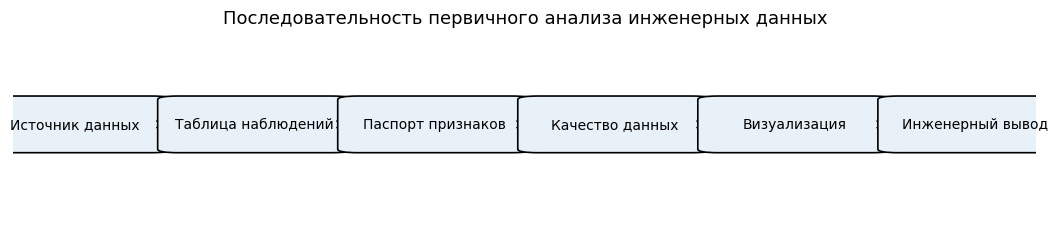

In [2]:
draw_process_diagram(
    [
        "Источник данных",
        "Таблица наблюдений",
        "Паспорт признаков",
        "Качество данных",
        "Визуализация",
        "Инженерный вывод",
    ],
    "Последовательность первичного анализа инженерных данных",
)


In [3]:
df = pd.read_csv(DATA_FILE)

print(f"Размер таблицы: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()


Размер таблицы: 240 строк, 13 столбцов


,sample_id,profile_id,speed_rpm,torque_nm,voltage_v,current_a,ambient_temp_c,winding_resistance_ohm,temperature_c,output_power_w,loss_power_w,efficiency,torque_limit_nm
0,1,5,53239.2,0.03825,60.287,4.4753,27.517,0.202108,50.682,213.265,56.539,0.79044,0.06194
1,2,4,42797.5,0.03734,59.527,3.2896,27.289,0.193131,38.853,167.352,28.468,0.85462,0.07342
2,3,5,51693.1,0.04542,47.866,6.1663,24.352,0.203020,49.702,245.860,49.294,0.83299,0.06364
3,4,4,44529.0,0.05691,24.057,13.3402,32.707,0.207145,60.224,265.374,55.546,0.82692,0.07152
4,5,5,53440.8,0.02851,35.497,6.0066,26.001,0.202667,51.949,159.526,53.687,0.74820,0.06172


## Паспорт используемого учебного набора данных

Паспорт набора данных фиксирует происхождение, объект наблюдения, единицу
наблюдения и ограничения применимости. Такой паспорт нужен до построения
модели, поскольку он предотвращает ошибочную трактовку служебных столбцов,
расчетных величин и физически измеряемых величин как равноправных признаков.


In [4]:
base_dataset_passport = pd.DataFrame(
    {
        "parameter": [
            "Файл",
            "Объект",
            "Наблюдение",
            "Объем",
            "Основная цель занятия",
            "Физически измеряемые величины",
            "Расчетные величины",
            "Служебные поля",
            "Учебные дефекты качества",
            "Ограничение применимости",
            "Энергетический баланс",
        ],
        "value": [
            DATA_FILE.name,
            "маломощный электромеханический преобразователь на постоянных магнитах",
            "один режим работы двигателя",
            f"{df.shape[0]} строк и {df.shape[1]} столбцов",
            "первичный анализ, проверка качества данных и постановка задачи",
            "скорость, момент, напряжение, ток, температуры",
            "выходная мощность, потери, КПД, предел момента",
            "sample_id, profile_id",
            "контролируемые пропуски и выбросы",
            "данные учебные; выводы нельзя переносить на конкретный двигатель без проверки",
            "мощность, потери и КПД согласованы с измеренными напряжением и током с учетом округления",
        ],
    }
)

base_dataset_passport


,parameter,value
0,Файл,practice_01_motor_measurements.csv
1,Объект,маломощный электромеханический преобразователь...
2,Наблюдение,один режим работы двигателя
3,Объем,240 строк и 13 столбцов
4,Основная цель занятия,"первичный анализ, проверка качества данных и п..."
5,Физически измеряемые величины,"скорость, момент, напряжение, ток, температуры"
6,Расчетные величины,"выходная мощность, потери, КПД, предел момента"
7,Служебные поля,"sample_id, profile_id"
8,Учебные дефекты качества,контролируемые пропуски и выбросы
9,Ограничение применимости,данные учебные; выводы нельзя переносить на ко...


## Описание столбцов

На первом этапе необходимо явно определить, какие столбцы являются признаками,
а какой столбец является целевой переменной. В данном занятии целевой
переменной для интерпретации выберем КПД `efficiency`.

Столбцы `output_power_w`, `loss_power_w`, `torque_limit_nm` и
`winding_resistance_ohm` рассматриваются как диагностические или производные.
Они полезны для проверки физической согласованности, но не входят в базовый
набор признаков. `winding_resistance_ohm` является расчетной оценкой
сопротивления обмотки по температуре с небольшим шумом измерения; при
одновременном использовании с `temperature_c` возможна сильная линейная
зависимость признаков, то есть коллинеарность (collinearity).


In [5]:
feature_columns = [
    "speed_rpm",
    "torque_nm",
    "voltage_v",
    "current_a",
    "ambient_temp_c",
    "temperature_c",
]
diagnostic_columns = [
    "winding_resistance_ohm",
    "output_power_w",
    "loss_power_w",
    "torque_limit_nm",
]
target_column = "efficiency"

column_description = pd.DataFrame(
    {
        "column": df.columns,
        "role": [
            "служебный идентификатор",
            "номер профиля измерения",
            "признак",
            "признак",
            "признак",
            "признак",
            "признак",
            "производный диагностический столбец",
            "признак",
            "расчетная величина",
            "расчетная величина",
            "целевая переменная",
            "инженерное ограничение",
        ],
        "unit": [
            "-",
            "-",
            "rpm",
            "N*m",
            "V",
            "A",
            "deg_C",
            "Ohm",
            "deg_C",
            "W",
            "W",
            "1",
            "N*m",
        ],
        "physical_meaning": [
            "номер наблюдения",
            "условный номер измерительного профиля",
            "частота вращения вала",
            "электромагнитный момент",
            "напряжение питания",
            "ток двигателя",
            "температура окружающей среды",
            "сопротивление обмотки при текущей температуре",
            "температура обмотки",
            "механическая выходная мощность",
            "потери мощности",
            "коэффициент полезного действия",
            "учебный предел момента для данной скорости",
        ],
        "use_note": [
            "не использовать как физический признак",
            "использовать для группировки или проверки профилей",
            "основной режимный признак",
            "основной режимный признак",
            "электрический признак",
            "электрический признак",
            "внешнее условие",
            "производный диагностический признак",
            "тепловой признак",
            "расчетная величина; проверять риск утечки",
            "расчетная величина; проверять риск утечки",
            "цель в занятиях 1-2",
            "не является измерением; используется для учебных ограничений",
        ],
    }
)
column_description


,column,role,unit,physical_meaning,use_note
0,sample_id,служебный идентификатор,-,номер наблюдения,не использовать как физический признак
1,profile_id,номер профиля измерения,-,условный номер измерительного профиля,использовать для группировки или проверки проф...
2,speed_rpm,признак,rpm,частота вращения вала,основной режимный признак
3,torque_nm,признак,N*m,электромагнитный момент,основной режимный признак
4,voltage_v,признак,V,напряжение питания,электрический признак
5,current_a,признак,A,ток двигателя,электрический признак
6,ambient_temp_c,признак,deg_C,температура окружающей среды,внешнее условие
7,winding_resistance_ohm,производный диагностический столбец,Ohm,сопротивление обмотки при текущей температуре,производный диагностический признак
8,temperature_c,признак,deg_C,температура обмотки,тепловой признак
9,output_power_w,расчетная величина,W,механическая выходная мощность,расчетная величина; проверять риск утечки


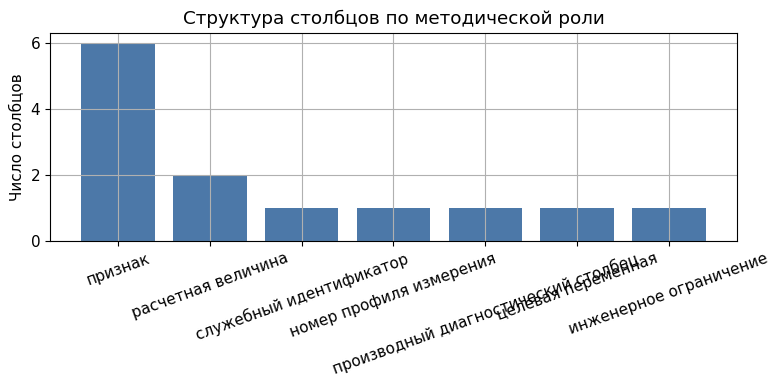

In [6]:
role_counts = column_description["role"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(role_counts.index, role_counts.values, color="#4c78a8")
ax.set_ylabel("Число столбцов")
ax.set_title("Структура столбцов по методической роли")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## Проверка пропусков

Пропуск - отсутствующее значение в таблице. В pandas пропуски обычно
отображаются как `NaN`. Перед обучением модели пропуски необходимо
обнаружить и обработать: удалить строки, заменить медианой или применить
более сложный метод восстановления.


## Стратегия обработки пропусков

Стратегия обработки пропусков (missing value strategy) должна выбираться до
построения модели. Сначала необходимо определить возможную причину пропуска:
отсутствие измерения, отказ датчика, невозможность расчета производной
величины или ошибка переноса данных. Только после этого выбирается действие.

Основные варианты обработки:

1. исключить наблюдение, если пропусков мало и удаление не искажает выборку;
2. заменить значение статистической оценкой, например медианой;
3. восстановить значение по физической или расчетной модели;
4. оставить пропуск и использовать его как индикатор качества измерения.

Медианная замена (median imputation) допустима в учебной задаче как простая и
воспроизводимая процедура. Однако она изменяет распределение признака и может
ослабить связь между физической величиной и целевой переменной. Поэтому в
отчете необходимо указать, какие столбцы были обработаны и почему выбран
именно этот способ.


In [7]:
missing_table = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_share=lambda x: x["missing_count"] / len(df))
)
missing_table[missing_table["missing_count"] > 0]


,missing_count,missing_share
torque_nm,6,0.025
current_a,6,0.025
temperature_c,6,0.025
efficiency,6,0.025


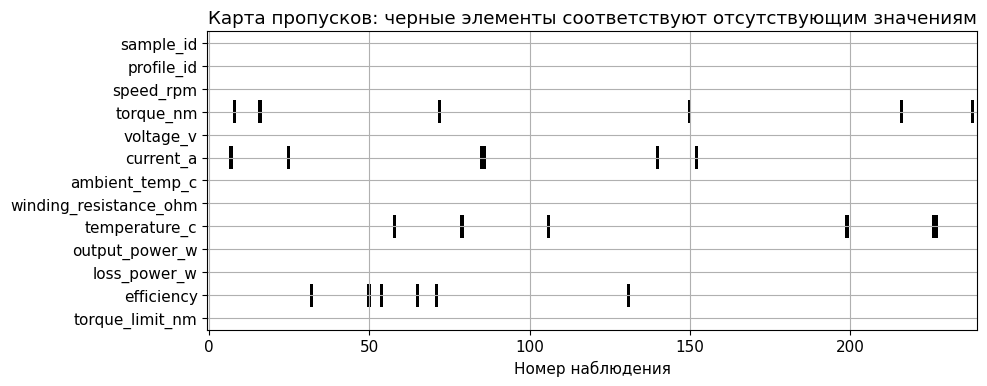

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_matrix = df.isna().astype(int).T
ax.imshow(missing_matrix, aspect="auto", cmap="Greys")
ax.set_yticks(range(len(df.columns)))
ax.set_yticklabels(df.columns)
ax.set_xlabel("Номер наблюдения")
ax.set_title("Карта пропусков: черные элементы соответствуют отсутствующим значениям")
plt.tight_layout()
plt.show()


## Контроль физической реализуемости

Перед интерпретацией графиков необходимо проверить простые физические
ограничения. Такие проверки не доказывают корректность набора данных, но
быстро выявляют грубые ошибки: отрицательную скорость, КПД вне диапазона от
0 до 1, неуникальные идентификаторы или несогласованность расчетной мощности.


In [9]:
physical_checks = pd.Series(
    {
        "sample_id_unique": df["sample_id"].is_unique,
        "speed_positive": bool((df["speed_rpm"].dropna() > 0).all()),
        "voltage_positive": bool((df["voltage_v"].dropna() > 0).all()),
        "current_positive": bool((df["current_a"].dropna() > 0).all()),
        "efficiency_between_0_and_1": bool(df["efficiency"].dropna().between(0, 1).all()),
        "torque_not_above_limit_after_dropna": bool(
            (df.dropna(subset=["torque_nm"])["torque_nm"] <= df.dropna(subset=["torque_nm"])["torque_limit_nm"]).all()
        ),
    },
    name="check_passed",
)

physical_checks.to_frame()


,check_passed
sample_id_unique,True
speed_positive,True
voltage_positive,True
current_positive,True
efficiency_between_0_and_1,True
torque_not_above_limit_after_dropna,True


In [10]:
physics_df = df.dropna(subset=["speed_rpm", "torque_nm", "output_power_w", "voltage_v", "current_a", "efficiency"]).copy()
physics_df["omega_rad_s"] = 2.0 * np.pi * physics_df["speed_rpm"] / 60.0
physics_df["recomputed_output_power_w"] = physics_df["torque_nm"] * physics_df["omega_rad_s"]
physics_df["input_power_w"] = physics_df["voltage_v"] * physics_df["current_a"]
physics_df["recomputed_efficiency"] = physics_df["recomputed_output_power_w"] / physics_df["input_power_w"]
physics_df["output_power_relative_error"] = (
    (physics_df["recomputed_output_power_w"] - physics_df["output_power_w"]).abs()
    / physics_df["output_power_w"].clip(lower=1e-9)
)

physics_summary = physics_df[
    [
        "recomputed_output_power_w",
        "input_power_w",
        "recomputed_efficiency",
        "output_power_relative_error",
    ]
].describe().T

physics_summary


,count,mean,std,min,25%,50%,75%,max
recomputed_output_power_w,222.0,140.473423,82.077635,8.922291e+00,73.642524,142.138415,200.419065,330.027007
input_power_w,222.0,188.030868,98.131541,1.508382e+01,100.678367,189.526967,259.868810,417.727290
recomputed_efficiency,222.0,0.716635,0.129408,2.780021e-01,0.627443,0.745922,0.814478,0.952588
output_power_relative_error,222.0,0.000083,0.000083,9.283270e-08,0.000032,0.000061,0.000109,0.000624


/tmp/ipykernel_6587/1986928158.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(profile_efficiency, labels=sorted(physics_df["profile_id"].unique()))


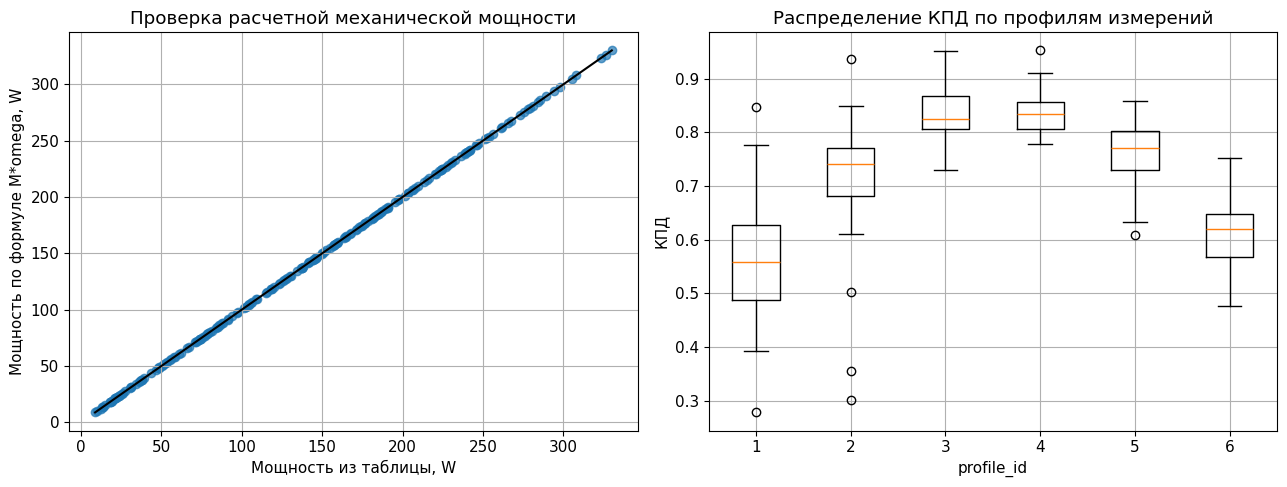

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    physics_df["output_power_w"],
    physics_df["recomputed_output_power_w"],
    alpha=0.70,
)
power_min = min(physics_df["output_power_w"].min(), physics_df["recomputed_output_power_w"].min())
power_max = max(physics_df["output_power_w"].max(), physics_df["recomputed_output_power_w"].max())
axes[0].plot([power_min, power_max], [power_min, power_max], color="black")
axes[0].set_xlabel("Мощность из таблицы, W")
axes[0].set_ylabel("Мощность по формуле M*omega, W")
axes[0].set_title("Проверка расчетной механической мощности")

profile_efficiency = [
    physics_df.loc[physics_df["profile_id"] == profile, "efficiency"]
    for profile in sorted(physics_df["profile_id"].unique())
]
axes[1].boxplot(profile_efficiency, labels=sorted(physics_df["profile_id"].unique()))
axes[1].set_xlabel("profile_id")
axes[1].set_ylabel("КПД")
axes[1].set_title("Распределение КПД по профилям измерений")

plt.tight_layout()
plt.show()


## Первичная статистика

Описательная статистика позволяет проверить порядок величин, диапазоны и
возможные аномалии. Следует сопоставлять числа с физическим смыслом: ток
измеряется в амперах, момент - в Н*м, скорость - в оборотах в минуту.


In [12]:
df[feature_columns + [target_column]].describe().T


,count,mean,std,min,25%,50%,75%,max
speed_rpm,240.0,35679.114167,18974.021123,5000.00000,19039.175000,35544.400000,53113.125000,65000.00000
torque_nm,234.0,0.040090,0.017553,0.00735,0.026932,0.039015,0.052840,0.08472
voltage_v,240.0,41.540442,11.910337,22.93800,35.539250,46.993000,48.096750,61.23500
current_a,234.0,4.977772,2.967125,0.25280,2.449575,4.773550,6.644075,17.28420
ambient_temp_c,240.0,27.739158,4.330229,20.02400,23.820000,27.858500,31.402750,34.82000
temperature_c,234.0,48.920765,13.393599,27.20900,38.681750,46.134000,56.603750,89.75700
efficiency,234.0,0.717233,0.131302,0.27800,0.625070,0.745980,0.817230,0.95267


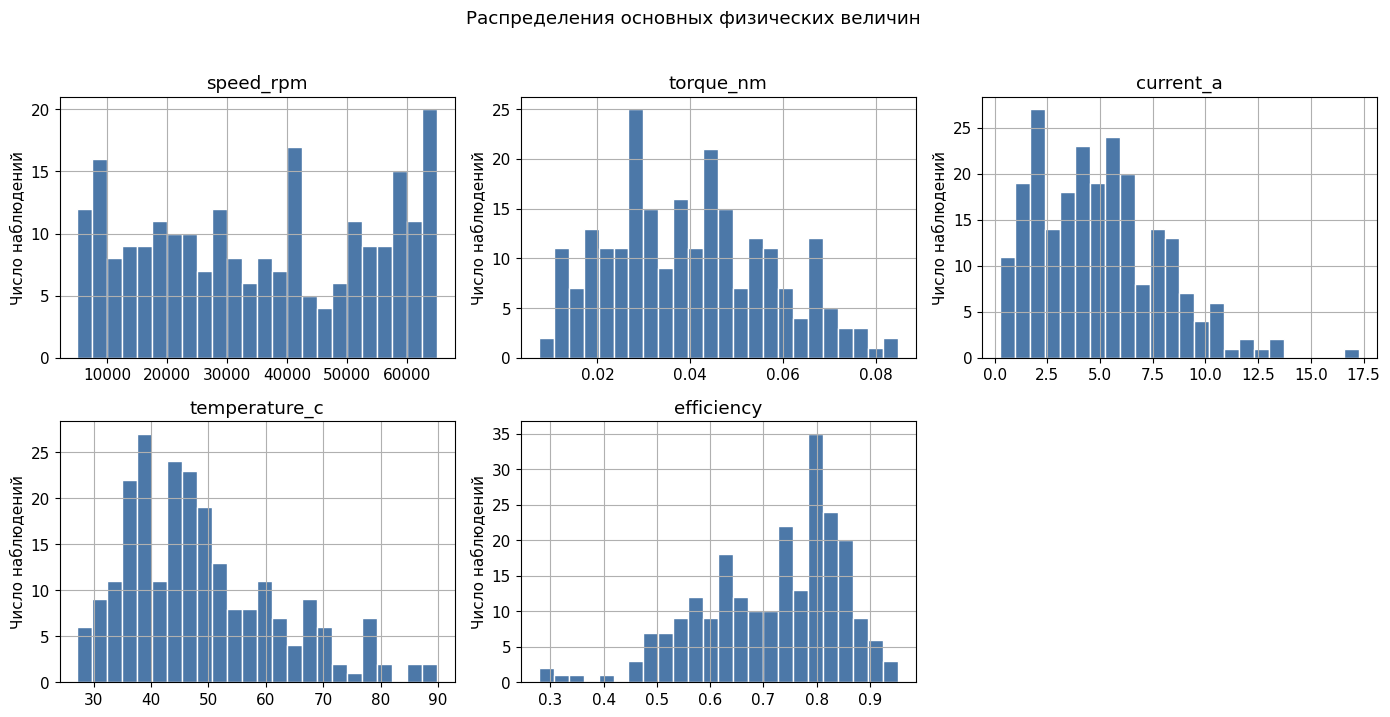

In [13]:
hist_columns = ["speed_rpm", "torque_nm", "current_a", "temperature_c", "efficiency"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, column in zip(axes, hist_columns):
    ax.hist(df[column].dropna(), bins=24, color="#4c78a8", edgecolor="white")
    ax.set_title(column)
    ax.set_ylabel("Число наблюдений")

axes[-1].set_axis_off()
plt.suptitle("Распределения основных физических величин", y=1.02)
plt.tight_layout()
plt.show()


## Визуальный анализ зависимостей

График рассеяния показывает, как пары величин связаны между собой. Он не
доказывает причинно-следственную связь, но помогает сформулировать инженерную
гипотезу.


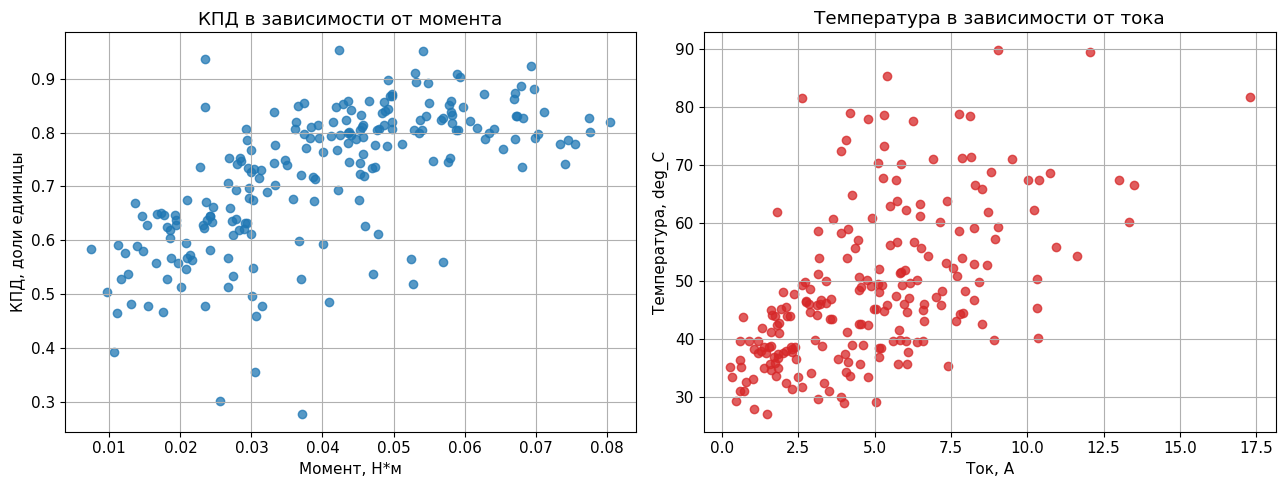

In [14]:
plot_df = df.dropna(subset=["torque_nm", "efficiency", "current_a", "temperature_c"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(plot_df["torque_nm"], plot_df["efficiency"], alpha=0.75)
axes[0].set_xlabel("Момент, Н*м")
axes[0].set_ylabel("КПД, доли единицы")
axes[0].set_title("КПД в зависимости от момента")

axes[1].scatter(plot_df["current_a"], plot_df["temperature_c"], alpha=0.75, color="tab:red")
axes[1].set_xlabel("Ток, А")
axes[1].set_ylabel("Температура, deg_C")
axes[1].set_title("Температура в зависимости от тока")

plt.tight_layout()
plt.show()


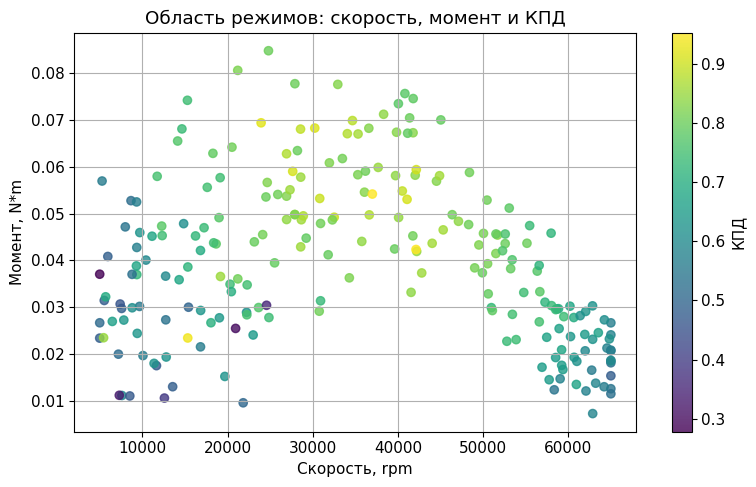

In [15]:
speed_torque_df = df.dropna(subset=["speed_rpm", "torque_nm", "efficiency"])

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    speed_torque_df["speed_rpm"],
    speed_torque_df["torque_nm"],
    c=speed_torque_df["efficiency"],
    cmap="viridis",
    alpha=0.80,
)
ax.set_xlabel("Скорость, rpm")
ax.set_ylabel("Момент, N*m")
ax.set_title("Область режимов: скорость, момент и КПД")
fig.colorbar(scatter, ax=ax, label="КПД")
plt.tight_layout()
plt.show()


## Поиск возможных выбросов

Выброс - наблюдение, резко отличающееся от основной массы данных. В
инженерных задачах выброс не всегда является ошибкой: это может быть
переходный режим, перегрузка или редкое рабочее состояние.

Ниже используется межквартильный размах (Interquartile Range, IQR). Это
разность между третьим и первым квартилем. Наблюдения вне интервала
`Q1 - 1.5 * IQR` и `Q3 + 1.5 * IQR` рассматриваются как кандидаты в выбросы.


In [16]:
def iqr_outlier_mask(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_columns = ["current_a", "temperature_c", "efficiency"]
outlier_summary = {}

for column in outlier_columns:
    mask = iqr_outlier_mask(df[column].dropna())
    outlier_summary[column] = int(mask.sum())

pd.Series(outlier_summary, name="candidate_outliers")


current_a        4
temperature_c    4
efficiency       3
Name: candidate_outliers, dtype: int64

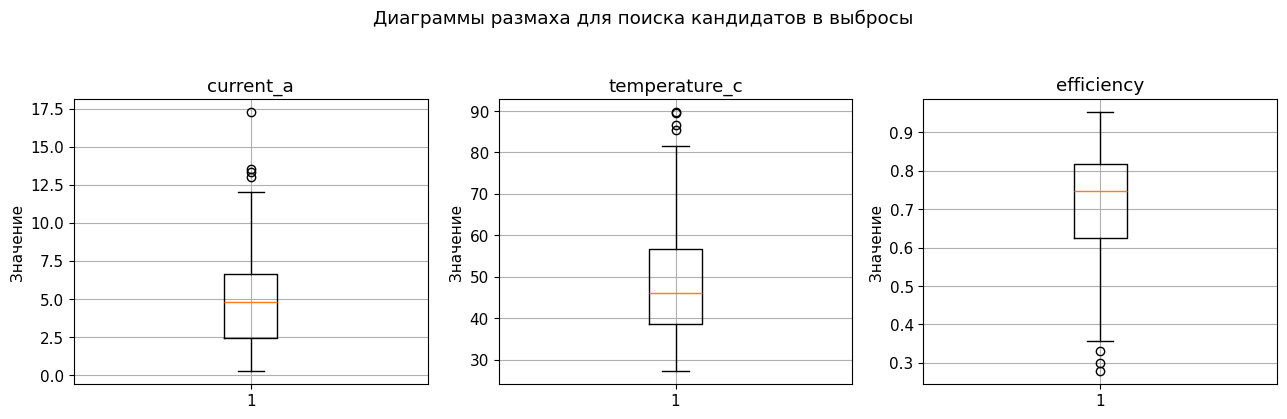

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, column in zip(axes, outlier_columns):
    ax.boxplot(df[column].dropna(), vert=True)
    ax.set_title(column)
    ax.set_ylabel("Значение")

plt.suptitle("Диаграммы размаха для поиска кандидатов в выбросы", y=1.04)
plt.tight_layout()
plt.show()


## Простейшая очистка данных

Для учебной задачи применим медианную замену пропусков. Медиана менее
чувствительна к выбросам, чем среднее арифметическое. В реальной работе
выбор метода обработки пропусков должен быть обоснован причиной их появления.


## Предупреждение о пересчете целевой переменной

Пропуски в исходной таблице внесены после расчета производных энергетических
величин. Поэтому в отдельных строках может сохраняться `output_power_w`, хотя
соответствующий первичный столбец `torque_nm` содержит пропуск. Это намеренный
учебный артефакт: студент должен обнаружить, что физический баланс нельзя
проверять механически без анализа происхождения столбцов.

После медианной замены первичных величин `torque_nm`, `current_a` и
`temperature_c` значения `output_power_w`, `loss_power_w` и `efficiency`
пересчитываются заново. Следовательно, часть значений `efficiency` в
`clean_df` получена не из исходных измерений, а из восстановленных медианой
значений. Такую таблицу допустимо использовать для демонстрации очистки
данных, но нельзя без пояснений переносить в регрессионную задачу занятия 2.


## Протокол преобразования данных

Протокол преобразования данных (data transformation protocol) фиксирует,
какие действия выполнены с исходной таблицей. Исходные значения не следует
перезаписывать без сохранения процедуры обработки. Воспроизводимый анализ
должен создавать очищенную копию данных и явно описывать все изменения.

Минимальный протокол включает:

1. перечень обработанных столбцов;
2. способ обработки пропусков;
3. правило работы с выбросами;
4. обоснование сохранения или исключения наблюдений;
5. проверку качества таблицы после преобразования.

В данном занятии выбросы не удаляются автоматически. Они рассматриваются как
кандидаты на дополнительную инженерную проверку, поскольку экстремальное
значение может соответствовать как ошибке измерения, так и редкому
допустимому режиму работы.


In [18]:
clean_df = df.copy()

# Пропуски заменяются только в первичных измеряемых столбцах.
# Расчетные энергетические величины после этого пересчитываются по формулам,
# чтобы не нарушать физический баланс таблицы.
primary_imputation_columns = ["torque_nm", "current_a", "temperature_c"]

for column in primary_imputation_columns:
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())

omega_rad_s = 2.0 * np.pi * clean_df["speed_rpm"] / 60.0
clean_df["output_power_w"] = clean_df["torque_nm"] * omega_rad_s
input_power_w = clean_df["voltage_v"] * clean_df["current_a"]
clean_df["loss_power_w"] = input_power_w - clean_df["output_power_w"]
clean_df["efficiency"] = clean_df["output_power_w"] / input_power_w

print("Число пропусков после обработки и пересчета:", int(clean_df.isna().sum().sum()))
clean_df[feature_columns + [target_column]].corr(numeric_only=True)[target_column].sort_values(ascending=False)


Число пропусков после обработки и пересчета: 0


efficiency        1.000000
torque_nm         0.618288
current_a         0.289616
voltage_v         0.142733
speed_rpm         0.138834
ambient_temp_c    0.094891
temperature_c     0.033922
Name: efficiency, dtype: float64

In [19]:
clean_balance_df = clean_df.copy()
clean_balance_df["omega_rad_s"] = 2.0 * np.pi * clean_balance_df["speed_rpm"] / 60.0
clean_balance_df["balance_output_power_w"] = (
    clean_balance_df["torque_nm"] * clean_balance_df["omega_rad_s"]
)
clean_balance_df["balance_relative_error"] = (
    (clean_balance_df["balance_output_power_w"] - clean_balance_df["output_power_w"]).abs()
    / clean_balance_df["output_power_w"].clip(lower=1e-9)
)

pd.Series(
    {
        "max_relative_error_after_cleaning": clean_balance_df["balance_relative_error"].max(),
        "mean_relative_error_after_cleaning": clean_balance_df["balance_relative_error"].mean(),
    },
    name="energy_balance_after_cleaning",
).to_frame("value")


,value
max_relative_error_after_cleaning,0.0
mean_relative_error_after_cleaning,0.0


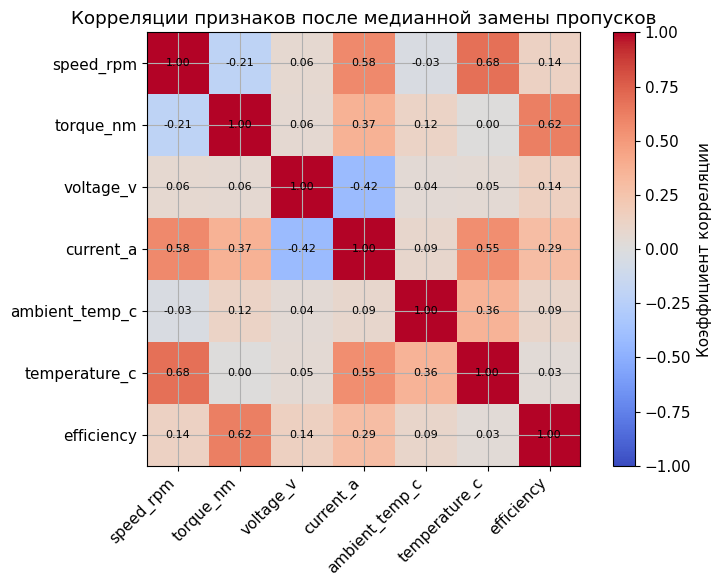

In [20]:
plot_correlation_heatmap(
    clean_df,
    feature_columns + [target_column],
    "Корреляции признаков после медианной замены пропусков",
)


## Переход от первичного анализа к постановке задачи машинного обучения

После первичного анализа необходимо зафиксировать, какая задача машинного
обучения может быть поставлена на подготовленных данных. Машинное обучение
(Machine Learning, ML) требует явного определения целевой переменной, входных
признаков, исключенных столбцов и критерия проверки качества.

Некоторые столбцы допустимы для объяснительного анализа, но недопустимы как
входные признаки модели. Например, `output_power_w` полезен для проверки
энергетического баланса, но при прогнозе КПД может привести к утечке данных,
поскольку КПД расчетно связан с мощностью.


In [21]:
ml_task_spec = pd.DataFrame(
    [
        {
            "task_type": "регрессия (regression)",
            "target": "efficiency",
            "allowed_features": "speed_rpm, torque_nm, voltage_v, temperature_c, ambient_temp_c",
            "excluded_columns": "sample_id, profile_id, current_a, winding_resistance_ohm, output_power_w, loss_power_w, torque_limit_nm",
            "reason": "служебные, расчетные и физически тождественно связанные столбцы не должны раскрывать целевую переменную",
        },
        {
            "task_type": "классификация (classification)",
            "target": "производная метка допустимости режима",
            "allowed_features": "первичные измеряемые признаки и заранее разрешенные расчетные признаки",
            "excluded_columns": "mode_label, violation_count, признаки причин нарушений, запасы до ограничений",
            "reason": "модель не должна получать прямое описание правила разметки",
        },
    ]
)

ml_task_spec


,task_type,target,allowed_features,excluded_columns,reason
0,регрессия (regression),efficiency,"speed_rpm, torque_nm, voltage_v, temperature_c...","sample_id, profile_id, current_a, winding_resi...","служебные, расчетные и физически тождественно ..."
1,классификация (classification),производная метка допустимости режима,первичные измеряемые признаки и заранее разреш...,"mode_label, violation_count, признаки причин н...",модель не должна получать прямое описание прав...


In [22]:
data_quality_checklist = pd.Series(
    {
        "no_missing_after_cleaning": int(clean_df.isna().sum().sum()) == 0,
        "sample_id_unique": clean_df["sample_id"].is_unique,
        "efficiency_between_0_and_1": clean_df["efficiency"].between(0, 1).all(),
        "nonnegative_power": (clean_df["output_power_w"] >= 0).all(),
        "feature_columns_defined": len(feature_columns) > 0,
        "target_column_defined": target_column in clean_df.columns,
    },
    name="passed",
)

data_quality_checklist.to_frame()


,passed
no_missing_after_cleaning,True
sample_id_unique,True
efficiency_between_0_and_1,False
nonnegative_power,True
feature_columns_defined,True
target_column_defined,True


## Задание для аудиторного отчета

1. Укажите, какие столбцы являются признаками, а какой столбец является
   целевой переменной.
2. Приведите таблицу пропусков.
3. Вставьте два графика: КПД от момента и температуру от тока.
4. Опишите не менее одного возможного выброса и укажите, почему его нельзя
   удалять без инженерного объяснения.
5. Проверьте энергетический баланс по формулам из теоретического блока и
   укажите максимальную относительную ошибку пересчета `output_power_w`.
6. Сформулируйте индивидуальный вывод каждого участника группы: какой признак
   наиболее важен для первичного анализа КПД и почему.
7. В отчете явно разделите измеряемые, расчетные и служебные столбцы.

Ответ группы:


## Реестр найденных наборов данных и развернутые задания

В этом блокноте используются все найденные источники данных через единый
реестр. Реестр не загружает крупные внешние архивы автоматически. Он задает
отдельные расширенные задания, которые можно выполнять после базовой части
занятия.

Каждое задание включает:

1. теоретический блок - какие понятия и ограничения нужно объяснить;
2. практический блок - какие действия выполнить в Jupyter Notebook;
3. ожидаемые артефакты - какие таблицы, графики и выводы должны быть в отчете;
4. риски - какие ограничения источника необходимо учесть.

Ниже показаны все найденные наборы данных, а затем задания, относящиеся к
занятию 1.


In [23]:
dataset_catalog = pd.read_csv(CATALOG_FILE)
dataset_assignments = pd.read_csv(ASSIGNMENTS_FILE)

pd.set_option("display.max_colwidth", 120)

all_datasets_view = dataset_catalog[
    [
        "dataset_id",
        "name",
        "object",
        "license",
        "access",
        "size_note",
        "lessons",
        "risk_level",
        "implementation_status",
    ]
]
all_datasets_view


,dataset_id,name,object,license,access,size_note,lessons,risk_level,implementation_status
0,zenodo_motor_temperature,ElectricMotorTemperature,"электродвигатель, представленный многомерными временными рядами (multivariate time series)",CC BY 4.0,прямая загрузка Zenodo,"TRAIN около 104 МБ, TEST около 45 МБ; фрагменты длиной 60 отсчетов","1,2,3",средний,external_notebook_ready
1,pmsm_inverter_fault_zenodo,Comprehensive Dataset for Fault Detection and Diagnosis in Inverter-Driven PMSM Systems,"PMSM-инвертор, лабораторная диагностика",CC BY 4.0,прямая загрузка Zenodo,компактный архив около 1.1 МБ по данным карточки источника,"1,2,3",низкий,external_notebook_ready
2,ev_powertrain_efficiency,Processed Data for EV Powertrain Efficiency,электропривод транспортного средства,CC BY 4.0,Mendeley Data,размер на карточке не указан,"1,2",средний,external_notebook_ready
3,system_identification_electric_motor,Identifying the Physics Behind an Electric Motor,PMSM и двухуровневый IGBT-инвертор,Data files copyright original authors; условия переиздания неясны,Kaggle,около 40 млн образцов,"1,2",высокий,methodology_only
4,ipmsm_motor_parameters,Dataset for motor parameters of IPMSM,параметры и геометрия синхронного двигателя с внутренним расположением постоянных магнитов (Interior Permanent Magne...,CC BY-SA 4.0,Kaggle,CSV и изображения геометрии,"1,2",средний,methodology_only
5,pmsm_foc_mendeley,PMSM_FOC dataset,PMSM с Field Oriented Control,CC BY 4.0,Mendeley Data,размер на карточке не указан,"1,2,3",средний,methodology_only
6,permanent_magnet_dc_worm_motor,Permanent Magnet DC Worm Geared Motor Data,двигатель постоянного тока с червячным редуктором,CC BY 4.0,Mendeley Data,около 27 МБ по статье Data in Brief,"1,2,3",средний,methodology_only
7,uci_ai4i_2020,AI4I 2020 Predictive Maintenance Dataset,синтетическая промышленная установка,CC BY 4.0,прямой UCI-доступ без регистрации,"10 000 строк, 14 столбцов, около 510 КБ","1,3",низкий,methodology_only
8,figshare_three_phase_induction_fault,MOTOR FAULT DETECTION DATA,трехфазный асинхронный двигатель,CC BY 4.0,прямая загрузка Figshare,"около 5.16 ГБ, 10 CSV-файлов","1,3",высокий,methodology_only
9,paderborn_bearing,Paderborn University Bearing Data Center,электромеханический привод с подшипниковыми дефектами,CC BY-NC 4.0,прямые MATLAB-файлы с сайта университета,"32 состояния, 4 режима, 20 измерений на режим","1,3",высокий,methodology_only


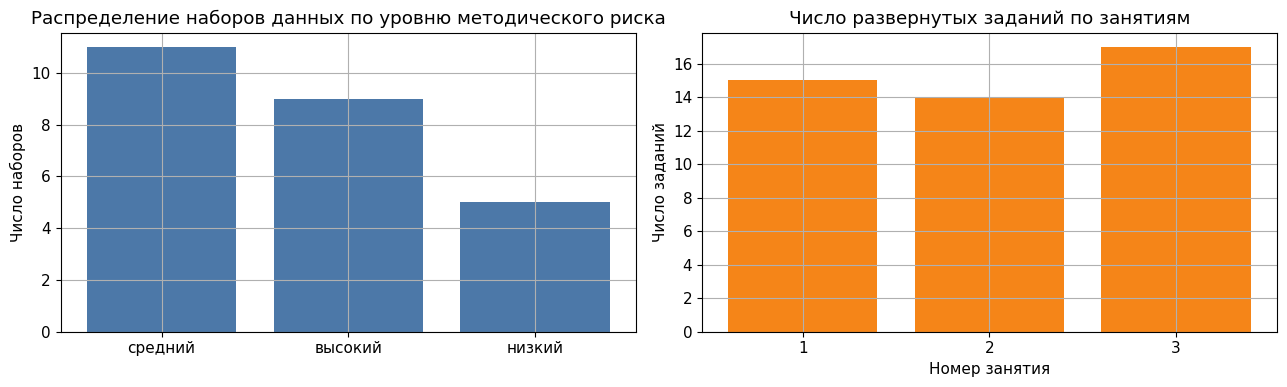

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

risk_counts = dataset_catalog["risk_level"].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values, color="#4c78a8")
axes[0].set_title("Распределение наборов данных по уровню методического риска")
axes[0].set_ylabel("Число наборов")

lesson_counts = (
    dataset_assignments["lesson"]
    .astype(str)
    .value_counts()
    .sort_index()
)
axes[1].bar(lesson_counts.index, lesson_counts.values, color="#f58518")
axes[1].set_title("Число развернутых заданий по занятиям")
axes[1].set_xlabel("Номер занятия")
axes[1].set_ylabel("Число заданий")

plt.tight_layout()
plt.show()


In [25]:
lesson_assignments = dataset_assignments[
    dataset_assignments["lesson"].astype(str) == "1"
].copy()

lesson_assignments[
    [
        "assignment_id",
        "assignment_title",
        "implementation_status",
        "dataset_structure",
        "minimum_working_subset",
        "target_rule",
        "split_rule",
        "theory_block",
        "practice_block",
        "recommended_visualizations",
        "expected_artifacts",
        "control_questions",
        "success_criteria",
        "risk_note",
    ]
]


,assignment_id,assignment_title,implementation_status,dataset_structure,minimum_working_subset,target_rule,split_rule,theory_block,practice_block,recommended_visualizations,expected_artifacts,control_questions,success_criteria,risk_note
0,zenodo_motor_temperature_eda,Первичный анализ данных: ElectricMotorTemperature,external_notebook_ready,"Объект: электродвигатель, представленный многомерными временными рядами (multivariate time series). Формат данных: T...",Использовать компактный CSV из `data/processed/external`; при чтении исходного .ts-файла сохранять profile_id и не п...,Целевая переменная может не задаваться; требуется описать возможные цели для последующих занятий.,Разбивать по profile_id или по временным блокам; случайное перемешивание соседних фрагментов не применять.,"Теоретический блок должен раскрыть структуру инженерного набора данных. Необходимо определить, что является наблюден...","Практический блок включает загрузку полного набора или подготовленного подмножества, построение паспорта столбцов, р...",1. Гистограммы ключевых физических признаков. 2. Диаграмма размаха (boxplot) для поиска кандидатов в выбросы. 3. Диа...,"Паспорт набора данных, таблица признаков с единицами измерения, таблица пропусков, таблица описательной статистики, ...",Что является наблюдением в данном источнике? Какие признаки имеют физические единицы измерения? Какие столбцы нельзя...,"Зачет: паспорт данных, таблица пропусков, не менее 3 графиков, вывод о пригодности источника.",физические имена каналов в архиве не заданы; требуется групповое разбиение по profile_id
3,pmsm_inverter_fault_zenodo_eda,Первичный анализ данных: Comprehensive Dataset for Fault Detection and Diagnosis in Inverter-Driven PMSM Systems,external_notebook_ready,"Объект: PMSM-инвертор, лабораторная диагностика. Формат данных: CSV / zip. Размер или масштаб: компактный архив окол...","Для базовой работы использовать полный файл, если он загружается менее чем за 2-3 минуты.",Целевая переменная может не задаваться; требуется описать возможные цели для последующих занятий.,Разбиение на обучение и тест не требуется; порядок строк сохранять до первичного анализа.,"Теоретический блок должен раскрыть структуру инженерного набора данных. Необходимо определить, что является наблюден...","Практический блок включает загрузку полного набора или подготовленного подмножества, построение паспорта столбцов, р...",1. Гистограммы ключевых физических признаков. 2. Диаграмма размаха (boxplot) для поиска кандидатов в выбросы. 3. Диа...,"Паспорт набора данных, таблица признаков с единицами измерения, таблица пропусков, таблица описательной статистики, ...",Что является наблюдением в данном источнике? Какие признаки имеют физические единицы измерения? Какие столбцы нельзя...,"Зачет: паспорт данных, таблица пропусков, не менее 3 графиков, вывод о пригодности источника.","исходная постановка ближе к диагностике, чем к расчету КПД"
6,ev_powertrain_efficiency_eda,Первичный анализ данных: Processed Data for EV Powertrain Efficiency,external_notebook_ready,Объект: электропривод транспортного средства. Формат данных: CSV и Jupyter Notebook. Размер или масштаб: размер на к...,"Для базовой работы использовать полный файл, если он загружается менее чем за 2-3 минуты.",Целевая переменная может не задаваться; требуется описать возможные цели для последующих занятий.,Разбиение на обучение и тест не требуется; порядок строк сохранять до первичного анализа.,"Теоретический блок должен раскрыть структуру инженерного набора данных. Необходимо определить, что является наблюден...","Практический блок включает загрузку полного набора или подготовленного подмножества, построение паспорта столбцов, р...",1. Гистограммы ключевых физических признаков. 2. Диаграмма размаха (boxplot) для поиска кандидатов в выбросы. 3. Диа...,"Паспорт набора данных, таблица признаков с единицами измерения, таблица пропусков, таблица описательной статистики, ...",Что является наблюдением в данном источнике? Какие признаки имеют физически

## Индивидуальное расширенное задание

Выберите один набор данных из таблицы выше и выполните соответствующее
развернутое задание. Если источник требует учетной записи, крупной загрузки
или специального формата файлов, допускается использовать малое заранее
подготовленное подмножество. В отчете обязательно укажите, была ли работа
выполнена на полном наборе данных, подмножестве или только на методическом
описании источника.


## Методический комментарий для преподавателя

Ориентиры для проверки:

1. таблица содержит 240 наблюдений и 13 столбцов;
2. в столбцах `torque_nm`, `current_a`, `temperature_c`, `efficiency`
   должно быть по 6 пропусков;
3. возможные выбросы должны обсуждаться как кандидаты, а не автоматически
   удаляться;
4. корректный вывод должен связывать КПД с режимом работы, а температуру -
   с током и потерями.


In [26]:
print("Контрольная проверка числа пропусков")
print(df[["torque_nm", "current_a", "temperature_c", "efficiency"]].isna().sum())

print("\nКорреляции с КПД после медианной замены")
print(clean_df[feature_columns + [target_column]].corr(numeric_only=True)[target_column].sort_values(ascending=False))


Контрольная проверка числа пропусков
torque_nm        6
current_a        6
temperature_c    6
efficiency       6
dtype: int64

Корреляции с КПД после медианной замены
efficiency        1.000000
torque_nm         0.618288
current_a         0.289616
voltage_v         0.142733
speed_rpm         0.138834
ambient_temp_c    0.094891
temperature_c     0.033922
Name: efficiency, dtype: float64
